In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, auc, confusion_matrix, accuracy_score)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


In [2]:
data_path = "pd_speech_features.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"\n❌ Dataset not found at: {data_path}\n"
        "Please download 'pd_speech_features.csv' and place it in the same "
        "directory as this script, or update the 'data_path' variable."
    )

# The CSV has a multi-row header (row 0 is a group label, row 1 is column names)
# Skip row 0 (group labels) and use row 1 as the header
df = pd.read_csv(data_path, sep=',', skiprows=1)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nCheck if 'class' exists:", 'class' in df.columns)

Dataset Shape: (756, 755)

First 5 rows:
   id  gender      PPE      DFA     RPDE  numPulses  numPeriodsPulses  \
0   0       1  0.85247  0.71826  0.57227        240               239   
1   0       1  0.76686  0.69481  0.53966        234               233   
2   0       1  0.85083  0.67604  0.58982        232               231   
3   1       0  0.41121  0.79672  0.59257        178               177   
4   1       0  0.32790  0.79782  0.53028        236               235   

   meanPeriodPulses  stdDevPeriodPulses  locPctJitter  ...  \
0          0.008064            0.000087       0.00218  ...   
1          0.008258            0.000073       0.00195  ...   
2          0.008340            0.000060       0.00176  ...   
3          0.010858            0.000183       0.00419  ...   
4          0.008162            0.002669       0.00535  ...   

   tqwt_kurtosisValue_dec_28  tqwt_kurtosisValue_dec_29  \
0                     1.5620                     2.6445   
1                     1.5589 

In [3]:
X = df.drop("class", axis=1)
y = df["class"]

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())


Feature matrix shape: (756, 754)
Target shape: (756,)

Class distribution:
class
1    564
0    192
Name: count, dtype: int64


In [4]:
var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X)
X_var = pd.DataFrame(X_var)

print("\nFeatures before variance filtering:", X.shape[1])
print("Features after variance filtering:", X_var.shape[1])



Features before variance filtering: 754
Features after variance filtering: 428


In [5]:
corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_filtered = X_var.drop(columns=to_drop)

print("\nFeatures before correlation filtering:", X_var.shape[1])
print("Features removed due to high correlation:", len(to_drop))
print("Features after correlation filtering:", X_filtered.shape[1])



Features before correlation filtering: 428
Features removed due to high correlation: 233
Features after correlation filtering: 195



Top 10 Important Features:
     Feature  MI Score
0          0  0.139577
34        36  0.097906
112      245  0.094158
115      258  0.090071
93       224  0.089607
8          9  0.085593
91       221  0.084491
45        47  0.082706
188      417  0.080602
113      246  0.075913


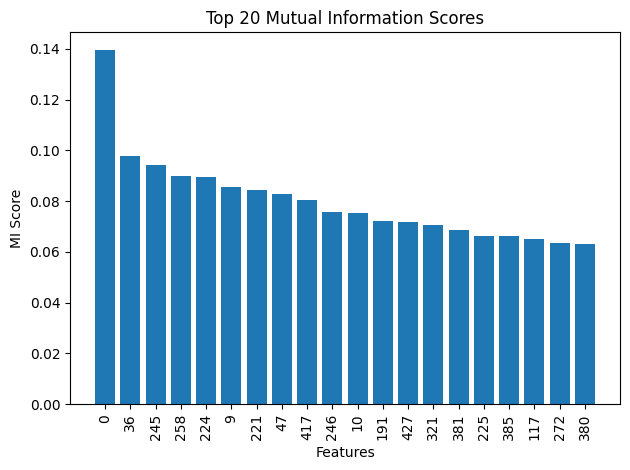

MI score plot saved as 'mi_scores.png'

Features before MI selection: 195
Features after MI selection: 80


In [6]:
mi_scores = mutual_info_classif(X_filtered, y)
mi_df = pd.DataFrame({"Feature": X_filtered.columns, "MI Score": mi_scores})
mi_df = mi_df.sort_values(by="MI Score", ascending=False)

print("\nTop 10 Important Features:")
print(mi_df.head(10))

# Plot top 20 MI scores
top_mi = mi_df.head(20)
plt.figure()
plt.bar(range(len(top_mi)), top_mi["MI Score"])
plt.xticks(range(len(top_mi)), top_mi["Feature"], rotation=90)
plt.title("Top 20 Mutual Information Scores")
plt.xlabel("Features")
plt.ylabel("MI Score")
plt.tight_layout()
plt.savefig("mi_scores.png", dpi=150)
plt.show()
print("MI score plot saved as 'mi_scores.png'")

# Select top 80 features
TOP_K = 80
selected_features = mi_df.head(TOP_K)["Feature"].values
X_mi = X_filtered[selected_features]

print("\nFeatures before MI selection:", X_filtered.shape[1])
print("Features after MI selection:", X_mi.shape[1])


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_mi, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling completed.")



Training shape: (604, 80)
Testing shape: (152, 80)
Scaling completed.


In [8]:
n_particles = 20
n_iterations = 25
w = 0.7    # inertia
c1 = 1.5   # cognitive
c2 = 1.5   # social

n_features = X_train_scaled.shape[1]

positions = np.random.randint(0, 2, (n_particles, n_features))
velocities = np.random.uniform(-1, 1, (n_particles, n_features))

pbest_positions = positions.copy()
pbest_scores = np.zeros(n_particles)

gbest_position = None
gbest_score = 0


def fitness_function(particle):
    selected = np.where(particle == 1)[0]
    if len(selected) == 0:
        return 0
    X_selected = X_train_scaled[:, selected]
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    score = cross_val_score(model, X_selected, y_train, cv=3).mean()
    penalty = len(selected) / n_features
    return 0.99 * score - 0.01 * penalty


print("\nRunning PSO Feature Selection...")
for iteration in range(n_iterations):
    for i in range(n_particles):
        score = fitness_function(positions[i])
        if score > pbest_scores[i]:
            pbest_scores[i] = score
            pbest_positions[i] = positions[i].copy()
        if score > gbest_score:
            gbest_score = score
            gbest_position = positions[i].copy()

    for i in range(n_particles):
        r1 = np.random.rand(n_features)
        r2 = np.random.rand(n_features)
        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest_positions[i] - positions[i])
            + c2 * r2 * (gbest_position - positions[i])
        )
        sigmoid = 1 / (1 + np.exp(-velocities[i]))
        positions[i] = np.where(np.random.rand(n_features) < sigmoid, 1, 0)

    print(f"Iteration {iteration+1}/{n_iterations}, Best Fitness: {gbest_score:.4f}")

print("\nPSO Completed ✅")

best_features_idx = np.where(gbest_position == 1)[0]
print("Number of features selected by PSO:", len(best_features_idx))

X_train_pso = X_train_scaled[:, best_features_idx]
X_test_pso = X_test_scaled[:, best_features_idx]



Running PSO Feature Selection...
Iteration 1/25, Best Fitness: 0.8581
Iteration 2/25, Best Fitness: 0.8634
Iteration 3/25, Best Fitness: 0.8634
Iteration 4/25, Best Fitness: 0.8634
Iteration 5/25, Best Fitness: 0.8634
Iteration 6/25, Best Fitness: 0.8634
Iteration 7/25, Best Fitness: 0.8634
Iteration 8/25, Best Fitness: 0.8634
Iteration 9/25, Best Fitness: 0.8634
Iteration 10/25, Best Fitness: 0.8634
Iteration 11/25, Best Fitness: 0.8634
Iteration 12/25, Best Fitness: 0.8634
Iteration 13/25, Best Fitness: 0.8634
Iteration 14/25, Best Fitness: 0.8634
Iteration 15/25, Best Fitness: 0.8634
Iteration 16/25, Best Fitness: 0.8634
Iteration 17/25, Best Fitness: 0.8650
Iteration 18/25, Best Fitness: 0.8650
Iteration 19/25, Best Fitness: 0.8650
Iteration 20/25, Best Fitness: 0.8650
Iteration 21/25, Best Fitness: 0.8650
Iteration 22/25, Best Fitness: 0.8650
Iteration 23/25, Best Fitness: 0.8650
Iteration 24/25, Best Fitness: 0.8650
Iteration 25/25, Best Fitness: 0.8650

PSO Completed ✅
Number o

In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

hybrid_model = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb)],
    voting='soft'
)

hybrid_model.fit(X_train_pso, y_train)
y_pred = hybrid_model.predict(X_test_pso)

accuracy = accuracy_score(y_test, y_pred)
print("\nFinal Hybrid Model Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Final Hybrid Model Accuracy: 0.868421052631579

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.56      0.69        39
           1       0.87      0.97      0.92       113

    accuracy                           0.87       152
   macro avg       0.87      0.77      0.80       152
weighted avg       0.87      0.87      0.86       152



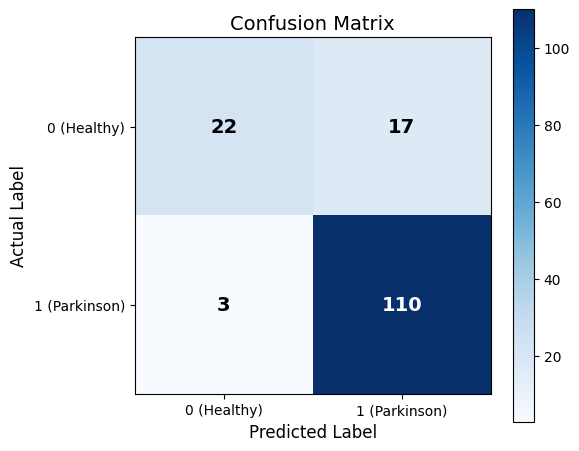

Confusion matrix saved as 'confusion_matrix.png'
Confusion Matrix:
 [[ 22  17]
 [  3 110]]


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.xticks([0, 1], ["0 (Healthy)", "1 (Parkinson)"])
plt.yticks([0, 1], ["0 (Healthy)", "1 (Parkinson)"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=14, fontweight="bold"
        )

plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")
print("Confusion Matrix:\n", cm)

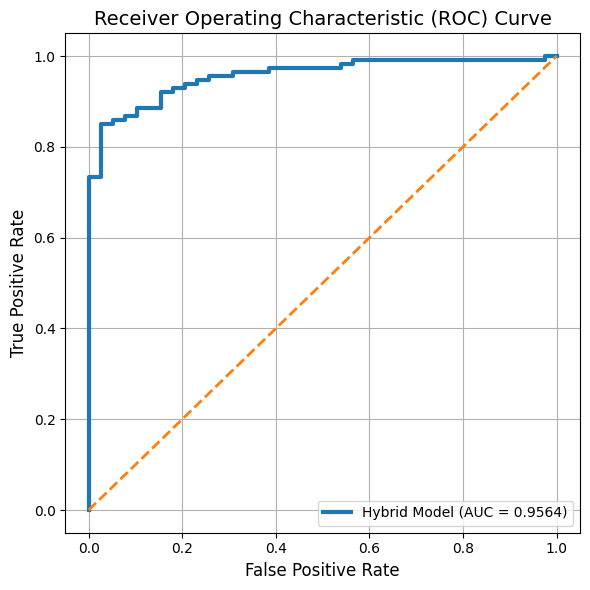

ROC curve saved as 'roc_curve.png'
Final AUC Score: 0.95643294758339


In [11]:
y_prob = hybrid_model.predict_proba(X_test_pso)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=3, label=f'Hybrid Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=2)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print("ROC curve saved as 'roc_curve.png'")
print("Final AUC Score:", roc_auc)
